# Tutorial 1: Rectangular Integration of RNA+ADT

In this tutorial, we demonstrate how to integrate a dataset consisting of RNA, and ADT data. We will also walk through the inference process and the some of the outputs generated by MIDAS.

## Step 1: Download the Demo Data

In [ ]:
from scmidas.data import download_data
download_data('wnn_full_3batch', './dataset')

## Step 2: Set Up the Environment

Before we begin, ensure that the required environment is set up. This includes importing the necessary packages and dependencies.

In [ ]:
import os
os.environ['CUDA_VISIBLE_DEVICES']='0'

from scmidas.config import load_config
from scmidas.model import MIDAS
from scmidas.utils import load_predicted
import lightning as L

import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt

sc.set_figure_params(figsize=(4, 4))

## Step 3: Configure the Model

In this step, we configure the model.

In [ ]:
configs = load_config() # refer to Tutotrials/Development Instructions for details

In [ ]:
task = 'wnn_full_3batch'
model = MIDAS.configure_data_from_dir(configs, './dataset/'+task+'/data')

INFO:root:Input data: 
         #CELL  #RNA  #ADT  #VALID_RNA  #VALID_ADT
BATCH 0   6378  3617   224        3617         224
BATCH 1   6952  3617   224        3617         224
BATCH 2   8908  3617   224        3617         224


## Step 4: Train the Model (~4h)

After configuring the model, we proceed with training. This step typically takes around 4 hours using a single V100 GPU, depending on your system's specifications. If you prefer a quicker result, you can set `max_epochs=500` for a reasonable outcome, instead of the default `max_epochs=2000` for the best result.

In [4]:
trainer = L.Trainer(max_epochs=2000)                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              
trainer.fit(model=model)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name | Type          | Params | Mode 
-----------------------------------------------
0 | net  | VAE           | 8.2 M  | train
1 | dsc  | Discriminator | 39.2 K | train
-----------------------------------------------
8.2 M     Trainable params
0         Non-trainable params
8.2 M     Total params
32.817    Total estimated model params size (MB)
154       Modules in train mode
0         Modules in eval mode
INFO:root:Total number of samples: 22238 from 3 datasets.
INFO:root:Using MultiBatchSampler for data loading.
/root/anaconda3/envs/pl/lib/python3.12/site-packages/torch/utils/data/sampler.py:76: UserWarning: `data_source` argument is not used and will be removed in 2.2.0.You may still have custom implementation that utilizes it.
  warnings.warn(
INFO:root:DataLoader created with batch size 256 and 20 workers.


Epoch 500: 100%|██████████| 105/105 [00:07<00:00, 14.72it/s, v_num=6, loss_/recon_loss_step=2.5e+3, loss_/kld_loss_step=105.0, loss_/consistency_loss_step=20.60, loss/net_step=2.53e+3, loss/dsc_step=97.70, loss_/recon_loss_epoch=2.34e+3, loss_/kld_loss_epoch=105.0, loss_/consistency_loss_epoch=21.40, loss/net_epoch=2.37e+3, loss/dsc_epoch=93.00] 

INFO:root:Checkpoint successfully saved to "./saved_models/model_epoch500_20241217-031018.pt".
INFO:root:Checkpoint saved for epoch "500" at "./saved_models/model_epoch500_20241217-031018.pt".


Epoch 1000: 100%|██████████| 105/105 [00:07<00:00, 14.16it/s, v_num=6, loss_/recon_loss_step=2.46e+3, loss_/kld_loss_step=104.0, loss_/consistency_loss_step=18.30, loss/net_step=2.48e+3, loss/dsc_step=93.10, loss_/recon_loss_epoch=2.3e+3, loss_/kld_loss_epoch=102.0, loss_/consistency_loss_epoch=20.60, loss/net_epoch=2.33e+3, loss/dsc_epoch=92.70]

INFO:root:Checkpoint successfully saved to "./saved_models/model_epoch1000_20241217-041043.pt".
INFO:root:Checkpoint saved for epoch "1000" at "./saved_models/model_epoch1000_20241217-041043.pt".


...

INFO:root:Checkpoint successfully saved to "./saved_models/model_epoch1500_20241217-051155.pt".
INFO:root:Checkpoint saved for epoch "1500" at "./saved_models/model_epoch1500_20241217-051155.pt".


Epoch 1999: 100%|██████████| 105/105 [00:06<00:00, 15.06it/s, v_num=6, loss_/recon_loss_step=2.38e+3, loss_/kld_loss_step=102.0, loss_/consistency_loss_step=18.00, loss/net_step=2.41e+3, loss/dsc_step=94.80, loss_/recon_loss_epoch=2.27e+3, loss_/kld_loss_epoch=101.0, loss_/consistency_loss_epoch=20.70, loss/net_epoch=2.3e+3, loss/dsc_epoch=92.80] 

`Trainer.fit` stopped: `max_epochs=2000` reached.


Epoch 1999: 100%|██████████| 105/105 [00:06<00:00, 15.03it/s, v_num=6, loss_/recon_loss_step=2.38e+3, loss_/kld_loss_step=102.0, loss_/consistency_loss_step=18.00, loss/net_step=2.41e+3, loss/dsc_step=94.80, loss_/recon_loss_epoch=2.27e+3, loss_/kld_loss_epoch=101.0, loss_/consistency_loss_epoch=20.70, loss/net_epoch=2.3e+3, loss/dsc_epoch=92.80]


INFO:root:Checkpoint successfully saved to "./saved_models/model_epoch2000_20241217-061343.pt".
INFO:root:Checkpoint saved for epoch "2000" at ./saved_models/model_epoch2000_20241217-061343.pt".


## Step 5: Predict

Once the model is trained, we can run `predict()` to obtain various outputs from MIDAS.

In [ ]:
model.predict('./predict/'+task,         
        joint_latent=True,
        mod_latent=True,
        impute=True,
        batch_correct=True,
        translate=True,
        input=True)

INFO:root:Predicting ...
INFO:root:Processing batch 0: ['rna', 'adt']
100%|██████████| 25/25 [01:18<00:00,  3.14s/it]
INFO:root:Processing batch 1: ['rna', 'adt']
100%|██████████| 28/28 [01:31<00:00,  3.27s/it]
INFO:root:Processing batch 2: ['rna', 'adt']
100%|██████████| 35/35 [01:46<00:00,  3.04s/it]
INFO:root:Calculating u_centroid ...
INFO:root:Loading predicted variables ...
INFO:root:Loading batch 0: z, joint
100%|██████████| 25/25 [00:00<00:00, 281.03it/s]
INFO:root:Loading batch 1: z, joint
100%|██████████| 28/28 [00:00<00:00, 298.36it/s]
INFO:root:Loading batch 2: z, joint
100%|██████████| 35/35 [00:00<00:00, 268.99it/s]
INFO:root:Converting to numpy ...
INFO:root:Converting batch 0: s, joint
INFO:root:Converting batch 0: z, joint
INFO:root:Converting batch 1: s, joint
INFO:root:Converting batch 1: z, joint
INFO:root:Converting batch 2: s, joint
INFO:root:Converting batch 2: z, joint
INFO:root:Batch correction ...
INFO:root:Processing batch 0: ['rna', 'adt']
100%|██████████| 2

## Outputs: Joint Embeddings

In this step, we explore the various outputs generated by MIDAS.
First, we load the cell-type and batch indice labels associated with the dataset.

In [ ]:
label = []
batch_id = []
for i in ['p1_0', 'p5_0', 'p8_0']:
    label.append(pd.read_csv('./dataset/'+task+'/label/%s.csv'%i, index_col=0).values.flatten())
    batch_id.append([i] * len(label[-1]))
labels = np.concatenate(label)
batch_ids = np.concatenate(batch_id)

The joint embeddings consist of two components: `biological information (c)` and `technical information (u)`.
To analyze them, we split the embeddings and visualize them separately.

INFO:root:Loading predicted variables ...
INFO:root:Loading batch 0: z, joint
100%|██████████| 25/25 [00:00<00:00, 190.18it/s]
INFO:root:Loading batch 1: z, joint
100%|██████████| 28/28 [00:00<00:00, 152.25it/s]
INFO:root:Loading batch 2: z, joint
100%|██████████| 35/35 [00:00<00:00, 67.57it/s]
INFO:root:Converting to numpy ...
INFO:root:Converting batch 0: s, joint
INFO:root:Converting batch 0: z, joint
INFO:root:Converting batch 1: s, joint
INFO:root:Converting batch 1: z, joint
INFO:root:Converting batch 2: s, joint
INFO:root:Converting batch 2: z, joint
/root/anaconda3/envs/pl/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
... storing 'batch' as categorical
... storing 'label' as categorical


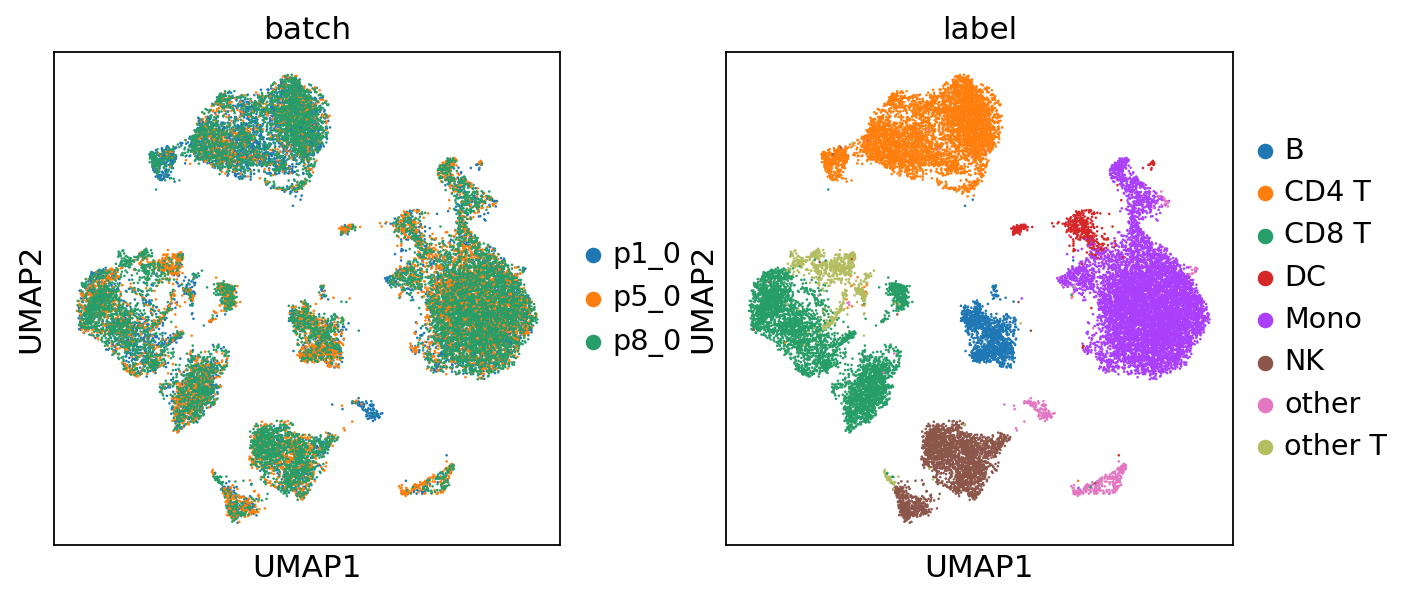

... storing 'batch' as categorical
... storing 'label' as categorical


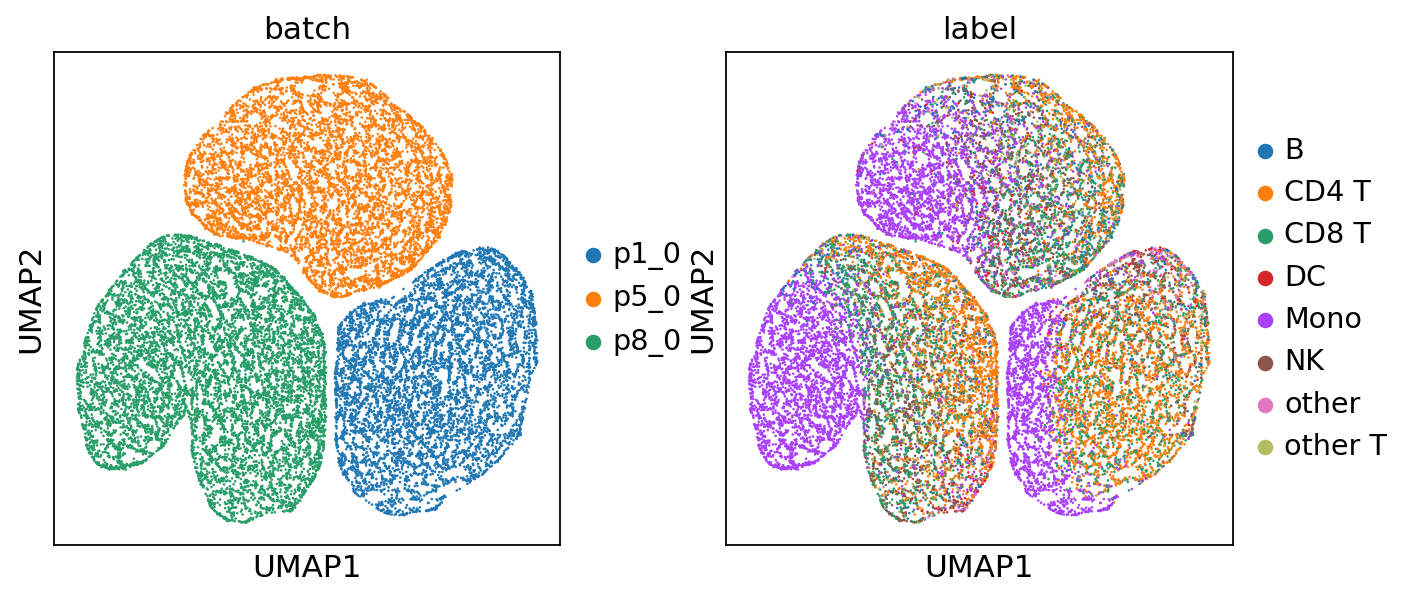

In [ ]:
#check the batch effect of raw counts (RNA)
joint_embeddings = load_predicted('./predict/'+task, model.s_joint, model.combs, model.mods, joint_latent=True)

adata_bio = sc.AnnData(joint_embeddings['z']['joint'][:, :model.dim_c])
adata_tech = sc.AnnData(joint_embeddings['z']['joint'][:, model.dim_c:])

adata_bio.obs['batch'] = batch_ids
adata_bio.obs['label'] = labels
adata_tech.obs['batch'] = batch_ids
adata_tech.obs['label'] = labels

for adata in [adata_bio, adata_tech]:
    sc.pp.neighbors(adata)
    sc.tl.umap(adata)
    sc.pl.umap(adata, color=['batch', 'label'], ncols=2)

For quick visualization of the joint embeddings, we provide an API that allows for efficient plotting.

INFO:root:Loading predicted data from: ../predict/wnn_full_047
INFO:root:Loading predicted variables ...
INFO:root:Loading batch 0: z, joint
100%|██████████| 25/25 [00:00<00:00, 169.07it/s]
INFO:root:Loading batch 1: z, joint
100%|██████████| 28/28 [00:00<00:00, 166.49it/s]
INFO:root:Loading batch 2: z, joint
100%|██████████| 35/35 [00:00<00:00, 168.41it/s]
INFO:root:Converting to numpy ...
INFO:root:Converting batch 0: s, joint
INFO:root:Converting batch 0: z, joint
INFO:root:Converting batch 1: s, joint
INFO:root:Converting batch 1: z, joint
INFO:root:Converting batch 2: s, joint
INFO:root:Converting batch 2: z, joint
INFO:root:Processing biological embedding...
INFO:root: - Computing neighbors...
INFO:root: - Computing UMAP...
INFO:root: - Generating UMAP plot for biological_embedding.png...
... storing 'batch' as categorical
INFO:root: - UMAP plot saved to: ./figs/biological_embedding.png
INFO:root:Processing technical embedding...
INFO:root: - Computing neighbors...
INFO:root: - C

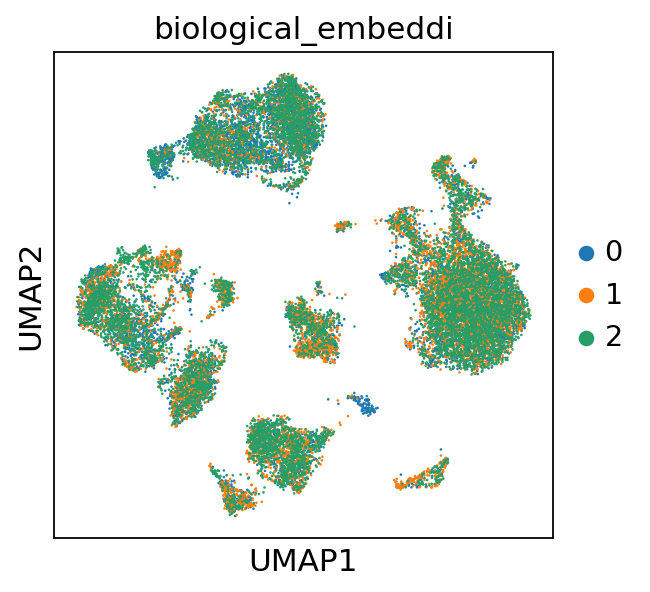

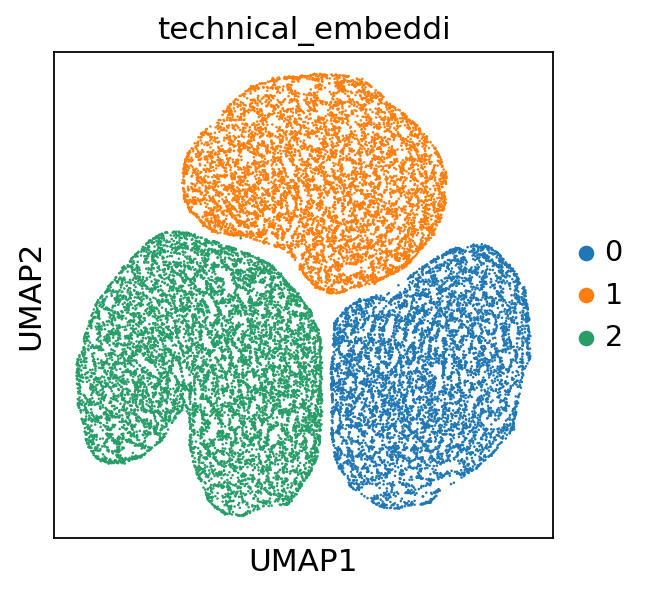

In [ ]:
adata, _ = model.get_emb_umap('./predict/'+task)

## Outputs: Modality-specific Embeddings

MIDAS can generate embeddings for each modality. Here, we check the alignment among modalities by visualizing them with UMAP.

In [ ]:
mod_embeddings = load_predicted('./predict/'+task, model.s_joint, model.combs, model.mods, mod_latent=True, group_by='batch')
batch_names = ['p1_0', 'p5_0', 'p8_0']
adata_list = []
for i in range(model.dims_s['joint']):
    for m in model.mods+['joint']:
        if m in mod_embeddings[i]['z']:
            adata = sc.AnnData(mod_embeddings[i]['z'][m][:, :model.dim_c])
            adata.obs['batch'] = batch_names[i]
            adata.obs['modality'] = m
            adata.obs['label'] = label[i]
            adata_list.append(adata)
adata_mod_concat = sc.concat(adata_list)
for i in adata_mod_concat.obs:
    adata_mod_concat.obs[i] = adata_mod_concat.obs[i].astype('category')
sc.pp.neighbors(adata_mod_concat)
sc.tl.umap(adata_mod_concat)

INFO:root:Loading predicted variables ...
INFO:root:Loading batch 0: z, joint
100%|██████████| 25/25 [00:00<00:00, 158.78it/s]
INFO:root:Loading batch 0: z, rna
100%|██████████| 25/25 [00:00<00:00, 291.56it/s]
INFO:root:Loading batch 0: z, adt
100%|██████████| 25/25 [00:00<00:00, 189.59it/s]
INFO:root:Loading batch 1: z, joint
100%|██████████| 28/28 [00:00<00:00, 161.27it/s]
INFO:root:Loading batch 1: z, rna
100%|██████████| 28/28 [00:00<00:00, 229.00it/s]
INFO:root:Loading batch 1: z, adt
100%|██████████| 28/28 [00:00<00:00, 267.90it/s]
INFO:root:Loading batch 2: z, joint
100%|██████████| 35/35 [00:00<00:00, 156.99it/s]
INFO:root:Loading batch 2: z, rna
100%|██████████| 35/35 [00:00<00:00, 217.53it/s]
INFO:root:Loading batch 2: z, adt
100%|██████████| 35/35 [00:00<00:00, 230.35it/s]
INFO:root:Converting to numpy ...
INFO:root:Converting batch 0: s, joint
INFO:root:Converting batch 0: s, rna
INFO:root:Converting batch 0: s, adt
INFO:root:Converting batch 0: z, joint
INFO:root:Convertin

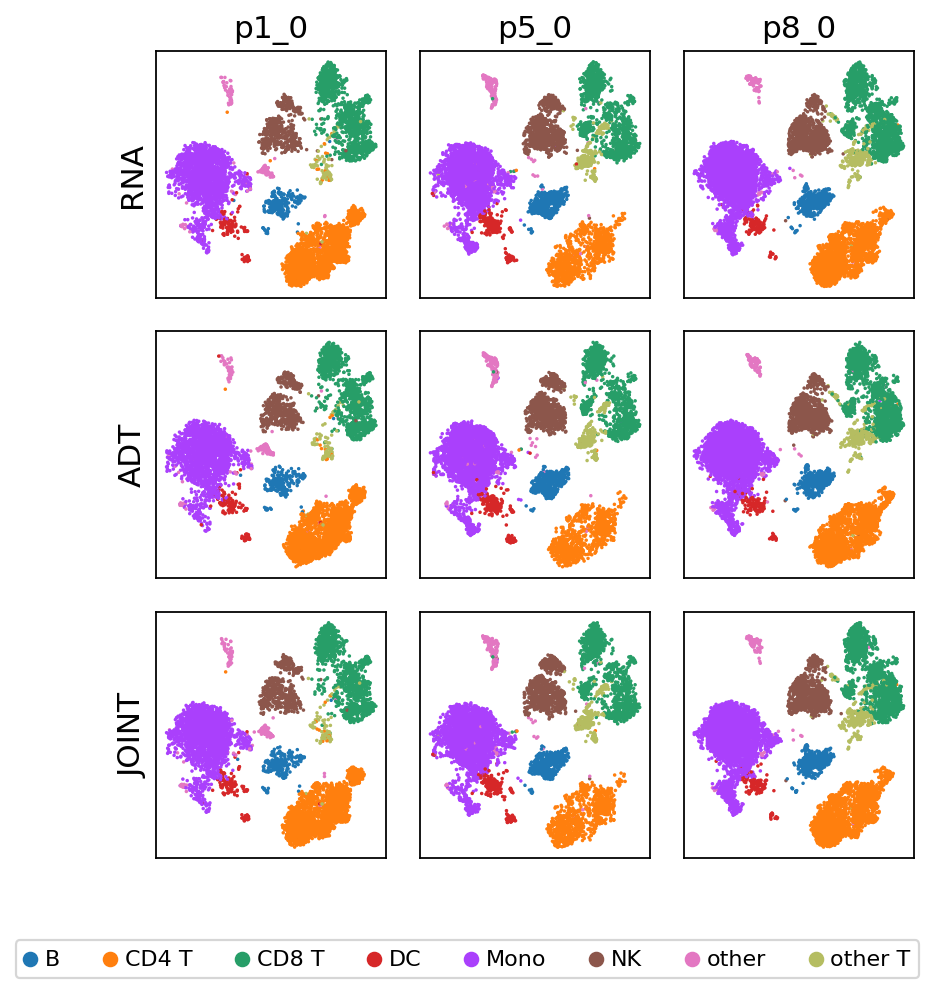

In [20]:
# setup figure
nrows = len(model.mods) + 1
ncols = model.dims_s['joint']
point_size = 10

fig, ax = plt.subplots(nrows, ncols, figsize=[2 * ncols, 2 * nrows])

# set up the name of modalities and batch
mod_names = model.mods + ['joint']

# iteratively scatter the data
for i, mod in enumerate(mod_names):
    for b in range(model.dims_s['joint']):
        # filter data
        adata = adata_mod_concat[
            (adata_mod_concat.obs['modality'] == mod) & 
            (adata_mod_concat.obs['batch'] == batch_names[b])
        ].copy()
        if len(adata):
            sc.pl.umap(adata, color='label', show=False, ax=ax[i, b], s=point_size)
            ax[i, b].get_legend().set_visible(False)
            handles, labels_ = ax[i, b].get_legend_handles_labels()
        ax[i, b].set_xticks([])
        ax[i, b].set_yticks([])
        ax[i, b].set_xlabel('')
        if b==0:
            ax[i, b].set_ylabel(mod.upper())
        else:
            ax[i, b].set_ylabel('')
        if i==0:
            ax[i, b].set_title(batch_names[b])
        else:
            ax[i, b].set_title('')
# create global legend
fig.legend(handles, labels_, loc='center', bbox_to_anchor=(0.5, -0.02), ncol=len(labels_), fontsize=10)

# adjust the figure
plt.tight_layout(rect=[0.1, 0.05, 1, 1])
plt.show()

## Outputs: Batch-corrected Counts

By using the `standard noise`, we can generate the batch-corrected data. To validate the batch effect in the predicted multi-modalities counts, we use PCA+WNN to gain the joint embeddings for them. First of all, we load the batch-corrected counts.

In [ ]:
batch_corrected_counts = load_predicted('./predict/'+task, model.s_joint, model.combs, model.mods, batch_correct=True)

INFO:root:Loading predicted variables ...
INFO:root:Loading batch 0: z, joint
100%|██████████| 25/25 [00:00<00:00, 285.87it/s]
INFO:root:Loading batch 0: x_bc, rna
100%|██████████| 25/25 [00:01<00:00, 21.59it/s]
INFO:root:Loading batch 0: x_bc, adt
100%|██████████| 25/25 [00:00<00:00, 111.07it/s]
INFO:root:Loading batch 1: z, joint
100%|██████████| 28/28 [00:00<00:00, 199.16it/s]
INFO:root:Loading batch 1: x_bc, rna
100%|██████████| 28/28 [00:01<00:00, 27.47it/s]
INFO:root:Loading batch 1: x_bc, adt
100%|██████████| 28/28 [00:00<00:00, 178.32it/s]
INFO:root:Loading batch 2: z, joint
100%|██████████| 35/35 [00:00<00:00, 238.94it/s]
INFO:root:Loading batch 2: x_bc, rna
100%|██████████| 35/35 [00:01<00:00, 26.51it/s]
INFO:root:Loading batch 2: x_bc, adt
100%|██████████| 35/35 [00:00<00:00, 168.43it/s]
INFO:root:Converting to numpy ...
INFO:root:Converting batch 0: s, joint
INFO:root:Converting batch 0: z, joint
INFO:root:Converting batch 0: x_bc, rna
INFO:root:Converting batch 0: x_bc, ad

In [ ]:
# https://github.com/dylkot/pyWNN, check the website for downloading the codes.
from pyWNN import pyWNN

Computing KNN distance matrices using default Scanpy implementation
Computing modality weights


/opt/data/private/zjh/code/midas_pl/src/pyWNN.py:192: RuntimeWarning: overflow encountered in exp
  self.weights.append( 1 / (1+ np.exp(affinity_ratios[1]-affinity_ratios[0])) )


Computing weighted distances for union of 200 nearest neighbors between modalities
0 out of 22238 0.01 seconds elapsed
2000 out of 22238 10.26 seconds elapsed
4000 out of 22238 21.16 seconds elapsed
6000 out of 22238 32.78 seconds elapsed
8000 out of 22238 43.16 seconds elapsed
10000 out of 22238 54.22 seconds elapsed
12000 out of 22238 65.20 seconds elapsed
14000 out of 22238 75.89 seconds elapsed
16000 out of 22238 86.43 seconds elapsed
18000 out of 22238 97.03 seconds elapsed
20000 out of 22238 107.59 seconds elapsed
22000 out of 22238 118.67 seconds elapsed
Selecting top K neighbors


/root/anaconda3/envs/pl/lib/python3.12/site-packages/umap/spectral.py:484: RuntimeWarning: divide by zero encountered in divide
  D = scipy.sparse.spdiags(1.0 / sqrt_deg, 0, graph.shape[0], graph.shape[0])
... storing 'label' as categorical
... storing 'batch' as categorical


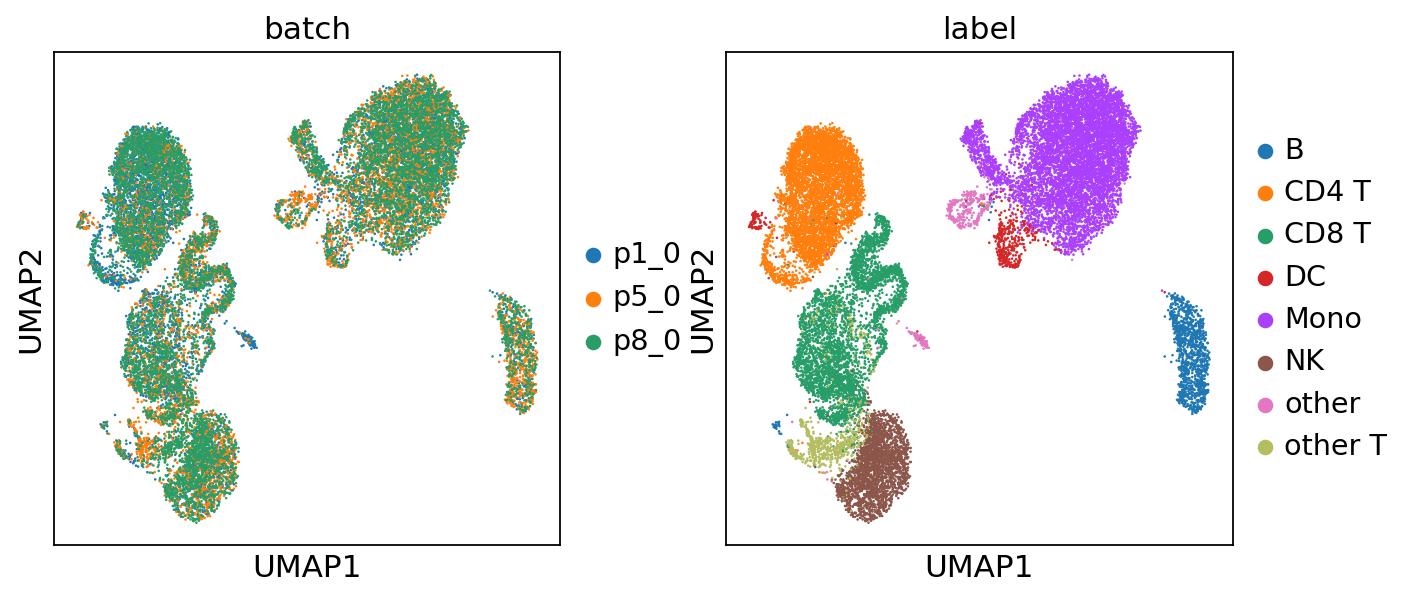

In [ ]:
rna_adata = sc.AnnData(batch_corrected_counts['x_bc']['rna'])
adt_adata = sc.AnnData(batch_corrected_counts['x_bc']['adt'])
sc.pp.pca(rna_adata)
sc.pp.pca(adt_adata)
adata = sc.AnnData(np.zeros([rna_adata.shape[0], 1]))
adata.obs['label'] = labels
adata.obs['batch'] = batch_ids
adata.obsm['RNA_PCA'] = rna_adata.obsm['X_pca']
adata.obsm['ADT_PCA'] = adt_adata.obsm['X_pca']
# To ensure consistency with our dimension settings, we use the top 32 principal components (PCs). 
WNNobj = pyWNN(adata, reps=['RNA_PCA', 'ADT_PCA'], npcs=[32,32], n_neighbors=20, seed=14)
adata = WNNobj.compute_wnn(adata)
sc.tl.umap(adata, neighbors_key='WNN')
sc.pl.umap(adata, color=['batch', 'label'])

Similarly, we load the raw counts and visualize the UMAP using the same procedure.

In [ ]:
inputs = load_predicted('../predict/'+task, model.s_joint, model.combs, model.mods, input=True, group_by='modality')

INFO:root:Loading predicted variables ...
INFO:root:Loading batch 0: z, joint
0it [00:00, ?it/s]
INFO:root:Loading batch 0: x, rna
100%|██████████| 25/25 [00:02<00:00,  8.96it/s]
INFO:root:Loading batch 0: x, adt
100%|██████████| 25/25 [00:00<00:00, 53.65it/s]
INFO:root:Loading batch 1: z, joint
0it [00:00, ?it/s]
INFO:root:Loading batch 1: x, rna
100%|██████████| 28/28 [00:02<00:00, 11.02it/s]
INFO:root:Loading batch 1: x, adt
100%|██████████| 28/28 [00:01<00:00, 19.57it/s]
INFO:root:Loading batch 2: z, joint
0it [00:00, ?it/s]
INFO:root:Loading batch 2: x, rna
100%|██████████| 35/35 [00:03<00:00, 10.56it/s]
INFO:root:Loading batch 2: x, adt
100%|██████████| 35/35 [00:00<00:00, 104.69it/s]
INFO:root:Converting to numpy ...
INFO:root:Converting batch 0: s, joint
INFO:root:Converting batch 0: z, joint
INFO:root:Converting batch 0: x, rna
INFO:root:Converting batch 0: x, adt
INFO:root:Converting batch 1: s, joint
INFO:root:Converting batch 1: z, joint
INFO:root:Converting batch 1: x, rna

Computing KNN distance matrices using default Scanpy implementation


/root/anaconda3/envs/pl/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Computing modality weights


/opt/data/private/zjh/code/midas_pl/src/pyWNN.py:192: RuntimeWarning: overflow encountered in exp
  self.weights.append( 1 / (1+ np.exp(affinity_ratios[1]-affinity_ratios[0])) )


Computing weighted distances for union of 200 nearest neighbors between modalities
0 out of 22238 0.01 seconds elapsed
2000 out of 22238 10.17 seconds elapsed
4000 out of 22238 20.34 seconds elapsed
6000 out of 22238 30.42 seconds elapsed
8000 out of 22238 42.04 seconds elapsed
10000 out of 22238 56.30 seconds elapsed
12000 out of 22238 70.45 seconds elapsed
14000 out of 22238 83.88 seconds elapsed
16000 out of 22238 94.16 seconds elapsed
18000 out of 22238 104.35 seconds elapsed
20000 out of 22238 114.79 seconds elapsed
22000 out of 22238 124.97 seconds elapsed
Selecting top K neighbors


/root/anaconda3/envs/pl/lib/python3.12/site-packages/umap/spectral.py:484: RuntimeWarning: divide by zero encountered in divide
  D = scipy.sparse.spdiags(1.0 / sqrt_deg, 0, graph.shape[0], graph.shape[0])
... storing 'label' as categorical
... storing 'batch' as categorical


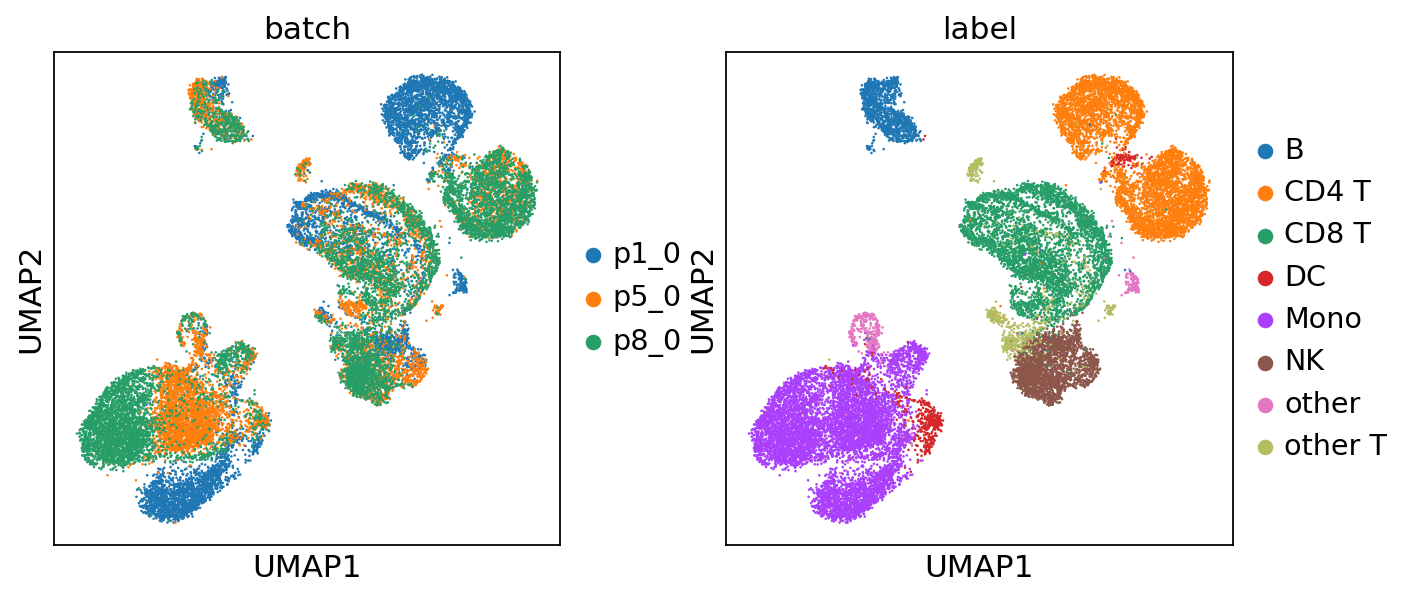

In [ ]:
rna_adata = sc.AnnData(inputs['x']['rna'])
adt_adata = sc.AnnData(inputs['x']['adt'])
sc.pp.pca(rna_adata)
sc.pp.pca(adt_adata)
adata = sc.AnnData(np.zeros([rna_adata.shape[0], 1]))
adata.obs['label'] = labels
adata.obs['batch'] = batch_ids
adata.obsm['RNA_PCA'] = rna_adata.obsm['X_pca']
adata.obsm['ADT_PCA'] = adt_adata.obsm['X_pca']
WNNobj = pyWNN(adata, reps=['RNA_PCA', 'ADT_PCA'], npcs=[32,32], n_neighbors=20, seed=14)
adata = WNNobj.compute_wnn(adata)
sc.tl.umap(adata, neighbors_key='WNN')
sc.pl.umap(adata, color=['batch', 'label'])

For the raw data, prominent batch effects are observed, where clusters of cells are segregated based on batches.
For the MIDAS batch-corrected counts, these batch effects are effectively removed, leading to well-integrated clusters.